In [80]:
import pandas as pd

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [82]:
from google.colab import files
uploaded = files.upload()
for filename in uploaded.keys():
    df = pd.read_csv(filename)

Saving exchange_rates.csv to exchange_rates (5).csv


In [83]:
#df = pd.read_csv('exchange_rates.csv')
df

,Series Description,SPOT EXCHANGE RATE - EURO AREA,"UNITED KINGDOM -- SPOT EXCHANGE RATE, US$/POUND (1/RXI_N.B.UK)",SPOT EXCHANGE RATE - BRAZIL,"CHINA -- SPOT EXCHANGE RATE, YUAN/US$ P.R.","DENMARK -- SPOT EXCHANGE RATE, KRONER/US$","INDIA -- SPOT EXCHANGE RATE, RUPEES/US$","JAPAN -- SPOT EXCHANGE RATE, YEN/US$","KOREA -- SPOT EXCHANGE RATE, WON/US$","MALAYSIA -- SPOT EXCHANGE RATE, RINGGIT/US$",...,"THAILAND -- SPOT EXCHANGE RATE, BAHT/US$",SPOT EXCHANGE RATE - VENEZUELA,Nominal Broad Dollar Index,Nominal Major Currencies Dollar Index,Nominal Other Important Trading Partners Dollar Index,AUSTRALIA -- SPOT EXCHANGE RATE US$/AU$ (RECIPROCAL OF RXI_N.B.AL),"NEW ZEALAND -- SPOT EXCHANGE RATE, US$/NZ$ RECIPROCAL OF RXI_N.B.NZ","CANADA -- SPOT EXCHANGE RATE, CANADIAN $/US$","HONG KONG -- SPOT EXCHANGE RATE, HK$/US$","SRI LANKA -- SPOT EXCHANGE RATE, RUPEES/US$"
0,Unit:,Currency:_Per_EUR,Currency:_Per_GBP,Currency:_Per_USD,Currency:_Per_USD,Currency:_Per_USD,Currency:_Per_USD,Currency:_Per_USD,Currency:_Per_USD,Currency:_Per_USD,...,Currency:_Per_USD,Currency:_Per_USD,Index:_1973_Mar_100,Index:_1973_Mar_100,Index:_1997_Jan_100,Currency:_Per_AUD,Currency:_Per_NZD,Currency:_Per_USD,Currency:_Per_USD,Currency:_Per_USD
1,Multiplier:,1,0.00999999978,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2,Currency:,USD,USD,BRL,CNY,DKK,INR,JPY,KRW,MYR,...,THB,VEB,NaN,NaN,NaN,USD,USD,CAD,HKD,LKR
3,Unique Identifier:,H10/H10/RXI$US_N.B.EU,H10/H10/RXI$US_N.B.UK,H10/H10/RXI_N.B.BZ,H10/H10/RXI_N.B.CH,H10/H10/RXI_N.B.DN,H10/H10/RXI_N.B.IN,H10/H10/RXI_N.B.JA,H10/H10/RXI_N.B.KO,H10/H10/RXI_N.B.MA,...,H10/H10/RXI_N.B.TH,H10/H10/RXI_N.B.VE,H10/H10/JRXWTFB_N.B,H10/H10/JRXWTFN_N.B,H10/H10/JRXWTFO_N.B,H10/H10/RXI$US_N.B.AL,H10/H10/RXI$US_N.B.NZ,H10/H10/RXI_N.B.CA,H10/H10/RXI_N.B.HK,H10/H10/RXI_N.B.SL
4,Time Period,RXI$US_N.B.EU,RXI$US_N.B.UK,RXI_N.B.BZ,RXI_N.B.CH,RXI_N.B.DN,RXI_N.B.IN,RXI_N.B.JA,RXI_N.B.KO,RXI_N.B.MA,...,RXI_N.B.TH,RXI_N.B.VE,JRXWTFB_N.B,JRXWTFN_N.B,JRXWTFO_N.B,RXI$US_N.B.AL,RXI$US_N.B.NZ,RXI_N.B.CA,RXI_N.B.HK,RXI_N.B.SL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12170,2017-08-21,1.1814,1.2903,3.1436,6.6630,6.2959,64.1000,108.8900,1137.1400,4.2855,...,33.2400,9.9750,119.1024,88.0441,152.4720,0.7936,0.7326,1.2587,7.8252,153.1000
12171,2017-08-22,1.1762,1.2834,3.1505,6.6600,6.3233,64.0700,109.4000,1131.7900,4.2790,...,33.2400,9.9750,119.1862,88.2744,152.3615,0.7913,0.7292,1.2559,7.8263,152.9000
12172,2017-08-23,1.1802,1.2787,3.1521,6.6569,6.3019,64.0400,109.1400,1128.5900,4.2780,...,33.3400,9.9750,119.1464,88.1510,152.4319,0.7893,0.7208,1.2558,7.8259,152.9000
12173,2017-08-24,1.1801,1.2802,3.1428,6.6600,6.3018,64.0400,109.3400,1127.8000,4.2780,...,33.3400,9.9750,119.0992,88.0944,152.3997,0.7905,0.7215,1.2528,7.8239,152.9000


In [84]:
df_australia = df[['Series Description','AUSTRALIA -- SPOT EXCHANGE RATE US$/AU$ (RECIPROCAL OF RXI_N.B.AL)']]
df_australia.describe()

,Series Description,AUSTRALIA -- SPOT EXCHANGE RATE US$/AU$ (RECIPROCAL OF RXI_N.B.AL)
count,12175,12175
unique,12175,4702
top,2017-08-25,ND
freq,1,468


In [85]:
# Se renombro la columna a "Exchange Rate" para facilitar su uso
df_australia = df_australia.rename(columns={'AUSTRALIA -- SPOT EXCHANGE RATE US$/AU$ (RECIPROCAL OF RXI_N.B.AL)': 'Exchange Rate'})

# Se cargó todo el `csv` brindando por el docente, por facilidad se modificó y se creó un nuevo df solo con los datos de `Australia` y las `fechas`. Se renombró la columna de Australia para facilitar su uso en todo el análisis.

In [86]:
df_australia.value_counts('Exchange Rate')

,count
Exchange Rate,
ND,468
1.1910,220
1.4850,106
1.4825,77
1.4150,75
...,...
0.4945,1
0.4944,1
0.4940,1


# Después de analizar las diferentes columnas se usarán los datos de Australia ya que cuenta con 4702 valores distintos y no tiene ningun valor null, pero si cuenta con 468 datos marcados como "ND", creemos que hace referencia a "No Data", se tomará la desición de imputar los datos para no afectar el módelo, ya que si se elimina sería casí un 10%, y en series de tiempo no es lo ideal.

### 1. Limpieza de Datos
Identificaremos los valores "ND" en la columna `Exchange Rate` y los reemplazaremos por una interpolación temporal para no perder la continuidad de la serie.

/tmp/ipykernel_6485/2317947065.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_australia['Date'] = pd.to_datetime(df_australia['Date'], errors='coerce')


Total de valores nulos después de la imputación: 0


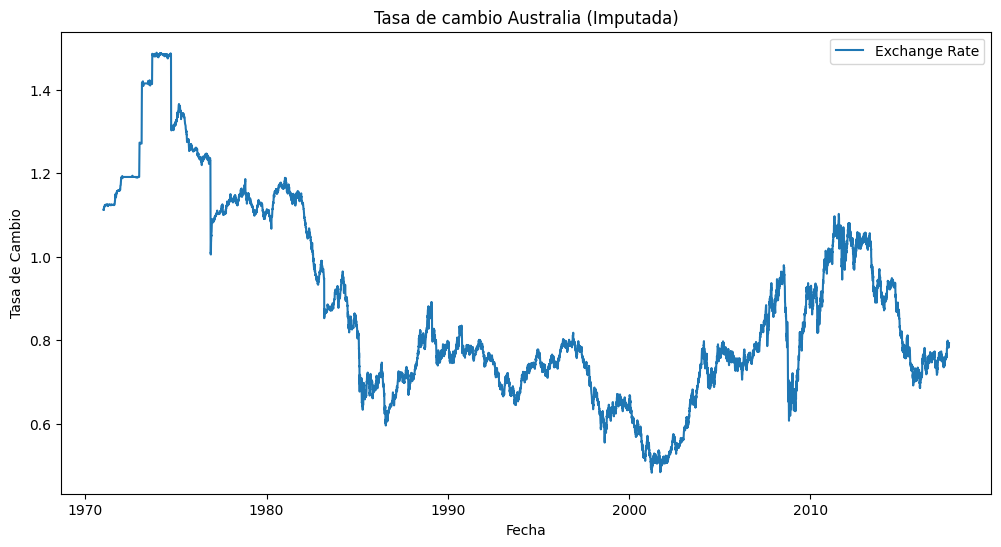

In [87]:
# Renombramos "Series Description" a "Date" para mayor claridad y limpiamos filas basura
if 'Series Description' in df_australia.columns:
    df_australia = df_australia.rename(columns={'Series Description': 'Date'})

# Intentamos convertir la columna Date a datetime. Las primeras filas que no son fechas quedarán como NaT y las eliminamos
df_australia['Date'] = pd.to_datetime(df_australia['Date'], errors='coerce')
df_australia = df_australia.dropna(subset=['Date'])
df_australia = df_australia.sort_values('Date').reset_index(drop=True)

# Reemplazar "ND" por NaN
df_australia['Exchange Rate'] = df_australia['Exchange Rate'].replace('ND', np.nan)
df_australia['Exchange Rate'] = pd.to_numeric(df_australia['Exchange Rate'], errors='coerce')

# Aplicar interpolación lineal para rellenar los datos faltantes
# Se usa interpolación lineal sobre ffill porque en las finanzas captura mejor las tendencias suaves entre dos puntos válidos
df_australia['Exchange Rate'] = df_australia['Exchange Rate'].interpolate(method='linear')

print(f"Total de valores nulos después de la imputación: {df_australia['Exchange Rate'].isnull().sum()}")
plt.figure(figsize=(12, 6))
plt.plot(df_australia['Date'], df_australia['Exchange Rate'], label='Exchange Rate')
plt.title('Tasa de cambio Australia (Imputada)')
plt.xlabel('Fecha')
plt.ylabel('Tasa de Cambio')
plt.legend()
plt.show()

### 2 y 3. Ventanas Temporales y Preparación de Datos para el Modelo
Se usa la regla de datos pasados ("lookback") para predecir un valor futuro ("horizonte"). Escalaremos los datos para facilitar el entrenamiento de la red profunda.

In [88]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Configuración de Ventanas
WINDOW_SIZE = 30 # Datos pasados
HORIZON = 1      # Horizonte de predicción

# Extraer solo la serie temporal
series_data = df_australia[['Exchange Rate']].values

# Escalar los datos (las redes neuronales prefieren datos entre 0 y 1 o -1 y 1)
scaler = MinMaxScaler(feature_range=(0, 1))
series_scaled = scaler.fit_transform(series_data)

X, y = [], []
for i in range(len(series_scaled) - WINDOW_SIZE - HORIZON + 1):
    X.append(series_scaled[i : i + WINDOW_SIZE, 0])
    # Predecir el siguiente valor después de la ventana
    y.append(series_scaled[i + WINDOW_SIZE + HORIZON - 1, 0])

X = np.array(X)
y = np.array(y)

# Dividir en Train y Test (80% / 20%) respetando el orden temporal
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")

Forma de X_train: (9712, 30)
Forma de y_train: (9712,)


### Arquitectura de Red Neuronal (Deep Learning)
Se usa un Multi Layer Perceptron (MLP) utilizando la API Sequential.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0172 - val_loss: 0.0030
Epoch 2/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0067 - val_loss: 0.0011
Epoch 3/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0046 - val_loss: 0.0010
Epoch 4/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0035 - val_loss: 0.0012
Epoch 5/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0034 - val_loss: 6.0133e-04
Epoch 6/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0030 - val_loss: 0.0016
Epoch 7/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0029 - val_loss: 0.0011
Epoch 8/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0027 - val_loss: 3.2245e-04
Epoch 9/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0027 - val_loss: 8.0583e-04
Epoch 10/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0025 - val_loss: 3.9011e-04
Epoch 11/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0024 - val_loss: 0.0017
Epoch 12/50
304/304 ━━━━━━━━━━━━━━━━

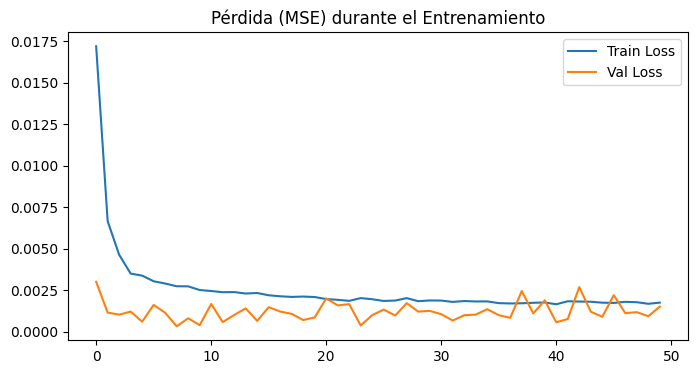

In [89]:
# 2. Arquitectura
model = Sequential([
    # Capa de entrada y primera capa oculta (relu nos ayuda a modelos no lineales sin saturación)
    Dense(64, activation='relu', input_shape=(WINDOW_SIZE,)),
    Dropout(0.2), # Añadimos Dropout para reducir el sobreajuste
    # Segunda capa oculta
    Dense(32, activation='relu'),
    Dropout(0.2), # Otro Dropout
    # Capa de salida continua
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Entrenar el modelo
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Evaluar el modelo visualmente en Loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Pérdida (MSE) durante el Entrenamiento')
plt.legend()
plt.show()

In [90]:
# Predicciones
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

# Invertir el escalado
train_predictions = scaler.inverse_transform(train_predictions)
test_predictions = scaler.inverse_transform(test_predictions)
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calcular RMSE
train_rmse = np.sqrt(mean_squared_error(y_train_inv, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test_inv, test_predictions))
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Train RMSE: 0.0563
Test RMSE: 0.0390


### 4. Interactividad
El usuario puede ingresar un rango de fechas para visualizar los datos históricos y la predicción generada que cae dentro de ese rango de fechas.

In [91]:
import ipywidgets as widgets
from IPython.display import display

# Preparar un dataframe con todas las predicciones para facilitar el filtrado por fechas
all_dates = df_australia['Date'].values[WINDOW_SIZE + HORIZON - 1:]
all_real = np.concatenate([y_train_inv, y_test_inv]).flatten()
all_preds = np.concatenate([train_predictions, test_predictions]).flatten()

df_results = pd.DataFrame({
    'Date': all_dates,
    'Real Exchange Rate': all_real,
    'Predicción NN': all_preds
})
df_results['Date'] = pd.to_datetime(df_results['Date'])

def plot_interactive_range(start_date, end_date):
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    mask = (df_results['Date'] >= start_date) & (df_results['Date'] <= end_date)
    df_filtered = df_results.loc[mask]

    if df_filtered.empty:
        print("No hay datos en este rango de fechas. Intente con un rango diferente (Ej. entre 1971 y 2011).")
        return

    plt.figure(figsize=(12, 6))
    plt.plot(df_filtered['Date'], df_filtered['Real Exchange Rate'], label='Real', marker='o', markersize=2)
    plt.plot(df_filtered['Date'], df_filtered['Predicción NN'], label='Predicción', alpha=0.8)

    plt.title(f'Tasa de Cambio Real vs Predicha ({start_date.date()} a {end_date.date()})')
    plt.xlabel('Fecha')
    plt.ylabel('Tasa de Cambio')
    plt.legend()
    plt.grid(True)
    plt.show()

# Widgets para seleccionar fechas
start_date_picker = widgets.DatePicker(
    description='Fecha Inicio',
    disabled=False,
    value=pd.to_datetime('2000-01-01').date()
)

end_date_picker = widgets.DatePicker(
    description='Fecha Fin',
    disabled=False,
    value=pd.to_datetime('2000-12-31').date()
)

interact_box = widgets.interactive(plot_interactive_range, start_date=start_date_picker, end_date=end_date_picker)
display(interact_box)

interactive(children=(DatePicker(value=datetime.date(2000, 1, 1), description='Fecha Inicio'), DatePicker(valu…

In [92]:
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Tomar los últimos datos escalados (del final de nuestro dataset) como base de partida
last_known_window = series_scaled[-WINDOW_SIZE:]
last_date = df_australia['Date'].iloc[-1]

def plot_future_forecast(meses_a_predecir):
    if meses_a_predecir <= 0:
        print("Mínimo 1 mes de predicción.")
        return

    # Asumimos que 1 mes ~ 22 días laborables/hábiles en Forex approx (o 30 calendario, usaremos 30 general)
    dias_a_predecir = meses_a_predecir * 30

    # Predecir iterativamente alimentando los inputs nuevos
    future_preds = []
    current_window = last_known_window.copy()

    for _ in range(dias_a_predecir):
        # La red espera un tensor con la forma (1, WINDOW_SIZE)
        pred = model.predict(current_window.reshape(1, WINDOW_SIZE), verbose=0)[0, 0]
        future_preds.append(pred)
        # Desplazamos la ventana: quitamos el más antiguo y añadimos la nueva predicción al final
        current_window = np.append(current_window[1:], [[pred]], axis=0)

    # Invertir el escalado de las predicciones a la magnitud real del Exchange Rate
    future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1)).flatten()

    # Generar rango de fechas futuras excluyendo fines de semana (comportamiento de bolsa local)
    future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=dias_a_predecir)

    # Contexto visual de los últimos 365 días reales
    context_days = 365
    hist_dates = df_australia['Date'].iloc[-context_days:]
    hist_values = df_australia['Exchange Rate'].iloc[-context_days:]

    plt.figure(figsize=(14, 6))
    plt.plot(hist_dates, hist_values, label='Datos Históricos (último año)', color='blue')
    plt.plot(future_dates, future_preds, label='Predicciones Futuras', color='crimson', linestyle='--')

    # Marcar evento de quiebre entre pasado y futuro predictivo
    plt.axvline(x=last_date, color='grey', linestyle=':', label='Fin datos reales')

    plt.title(f'Proyección de Tasa de Cambio (Forecasting iterativo {meses_a_predecir} meses)')
    plt.xlabel('Fecha')
    plt.ylabel('Tasa de Cambio')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Mostrar los valores numéricos de las predicciones
    df_forecast = pd.DataFrame({
        'Fecha': future_dates,
        'Predicción Tasa de Cambio': future_preds
    })
    print("\nValores numéricos de las predicciones futuras (primeras 10 filas):")
    display(df_forecast.head(10))
    if len(df_forecast) > 10:
        print(f"... y {len(df_forecast) - 10} filas más. Para ver todas, ajuste el slider o imprima `df_forecast`.")

# Widget deslizante interactivo
slider_meses = widgets.IntSlider(
    value=4,     # 4 meses permite visualizar el resto del año 2017
    min=1,
    max=60,      # Posibilidad de visualizar hasta 5 años en adelante
    step=1,
    description='Meses Futuros (n):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%')
)

interact_forecast = widgets.interactive(plot_future_forecast, meses_a_predecir=slider_meses)
display(interact_forecast)

interactive(children=(IntSlider(value=4, description='Meses Futuros (n):', layout=Layout(width='60%'), max=60,…

### Implementación de Red Neuronal LSTM (Long Short-Term Memory)
Para capturar mejor las dependencias secuenciales a largo plazo, configuraremos y entrenaremos un modelo LSTM. Adaptaremos nuestros datos de entrada porque las capas LSTM esperan un formato tridimensional: `(muestras, pasos_de_tiempo, características)`.

Forma original de X_train: (9712, 30)
Nueva forma de X_train_lstm: (9712, 30, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 30, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,301 (282.43 KB)

 Trainable params: 72,301 (282.43 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - loss: 0.0097 - val_loss: 5.5292e-04
Epoch 2/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - loss: 0.0015 - val_loss: 7.9154e-04
Epoch 3/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 0.0010 - val_loss: 3.9831e-04
Epoch 4/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - loss: 7.8290e-04 - val_loss: 2.8988e-04
Epoch 5/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - loss: 7.3759e-04 - val_loss: 3.5811e-04
Epoch 6/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - loss: 6.0459e-04 - val_loss: 2.8435e-04
Epoch 7/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 5.4725e-04 - val_loss: 7.0294e-04
Epoch 8/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 4.4313e-04 - val_loss: 4.6968e-04
Epoch 9/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - loss: 4.0294e-04 - val_loss: 3.0057e-04
Epoch 10/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - loss: 3.7758e-04 - val_loss: 4.7618e-04
Epoch 11/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/s

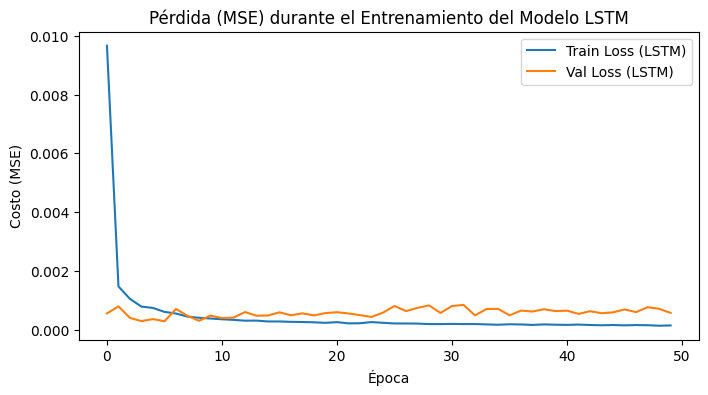

In [93]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Redimensionar los datos de [muestras, ventana] a [muestras, pasos de tiempo (ventana), características]
# La cantidad de características es 1 (la tasa de cambio)
X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"Forma original de X_train: {X_train.shape}")
print(f"Nueva forma de X_train_lstm: {X_train_lstm.shape}")

# Definir la arquitectura LSTM mejorada
lstm_model = Sequential([
    LSTM(100, activation='relu', input_shape=(WINDOW_SIZE, 1), return_sequences=True), # Primera capa LSTM, ahora retorna secuencias
    Dropout(0.2), # Dropout para reducir el sobreajuste
    LSTM(50, activation='relu', return_sequences=False), # Segunda capa LSTM
    Dropout(0.2), # Otro Dropout
    Dense(25, activation='relu'),
    Dense(1, activation='linear')
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

# Entrenar modelo
history_lstm = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=50, # Aumentamos las épocas para permitir más entrenamiento con la nueva arquitectura
    batch_size=32,
    validation_data=(X_test_lstm, y_test),
    verbose=1
)

# Evaluar visualmente el historial de pérdida
plt.figure(figsize=(8, 4))
plt.plot(history_lstm.history['loss'], label='Train Loss (LSTM)')
plt.plot(history_lstm.history['val_loss'], label='Val Loss (LSTM)')
plt.title('Pérdida (MSE) durante el Entrenamiento del Modelo LSTM')
plt.xlabel('Época')
plt.ylabel('Costo (MSE)')
plt.legend()
plt.show()

In [94]:
# Predicciones y cálculo del error con el modelo LSTM
train_predictions_lstm = lstm_model.predict(X_train_lstm)
test_predictions_lstm = lstm_model.predict(X_test_lstm)

# Invertir el escalado de nuevo a los valores reales
train_predictions_lstm = scaler.inverse_transform(train_predictions_lstm)
test_predictions_lstm = scaler.inverse_transform(test_predictions_lstm)

# Calcular RMSE
train_rmse_lstm = np.sqrt(mean_squared_error(y_train_inv, train_predictions_lstm))
test_rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, test_predictions_lstm))

print(f"LSTM Train RMSE: {train_rmse_lstm:.4f}")
print(f"LSTM Test RMSE: {test_rmse_lstm:.4f}")

# Reutilizamos el interactivo con pandas para ver qué tal se ajusta LSTM en la data de test
df_results_lstm = pd.DataFrame({
    'Date': all_dates,
    'Real Exchange Rate': all_real,
    'Predicción MLP': all_preds,
    'Predicción LSTM': np.concatenate([train_predictions_lstm, test_predictions_lstm]).flatten()
})
df_results_lstm['Date'] = pd.to_datetime(df_results_lstm['Date'])

def plot_interactive_lstm(start_date, end_date):
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    mask = (df_results_lstm['Date'] >= start_date) & (df_results_lstm['Date'] <= end_date)
    df_filtered = df_results_lstm.loc[mask]

    if df_filtered.empty:
        print("Selecciona un rango diferente.")
        return

    plt.figure(figsize=(12, 6))
    plt.plot(df_filtered['Date'], df_filtered['Real Exchange Rate'], label='Real', marker='o', markersize=2, color='blue')
    plt.plot(df_filtered['Date'], df_filtered['Predicción MLP'], label='Predicción MLP', alpha=0.6, color='orange')
    plt.plot(df_filtered['Date'], df_filtered['Predicción LSTM'], label='Predicción LSTM', alpha=0.8, color='green')

    plt.title(f'Comparativa de Tasas: Real, MLP y LSTM ({start_date.date()} a {end_date.date()})')
    plt.xlabel('Fecha')
    plt.ylabel('Tasa de Cambio')
    plt.legend()
    plt.grid(True)
    plt.show()

# Widgets para seleccionar fechas
start_date_picker_lstm = widgets.DatePicker(description='Fecha Inicio', disabled=False, value=pd.to_datetime('2007-01-01').date())
end_date_picker_lstm = widgets.DatePicker(description='Fecha Fin', disabled=False, value=pd.to_datetime('2009-12-31').date())

display(widgets.interactive(plot_interactive_lstm, start_date=start_date_picker_lstm, end_date=end_date_picker_lstm))

304/304 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
LSTM Train RMSE: 0.0407
LSTM Test RMSE: 0.0240


interactive(children=(DatePicker(value=datetime.date(2007, 1, 1), description='Fecha Inicio'), DatePicker(valu…

In [95]:
def plot_future_forecast_lstm(meses_a_predecir):
    if meses_a_predecir <= 0:
        print("Mínimo 1 mes de predicción.")
        return

    dias_a_predecir = meses_a_predecir * 30

    # Predecir iterativamente con LSTM
    future_preds_lstm = []
    current_window_lstm = last_known_window.copy().reshape((1, WINDOW_SIZE, 1))

    for _ in range(dias_a_predecir):
        pred = lstm_model.predict(current_window_lstm, verbose=0)[0, 0]
        future_preds_lstm.append(pred)
        # Desplazamos la ventana en el tensor 3D
        # Quitamos el primer elemento [0, 1:, :] y añadimos la nueva predicción al final
        new_val = np.array([[[pred]]])
        current_window_lstm = np.append(current_window_lstm[:, 1:, :], new_val, axis=1)

    future_preds_lstm = scaler.inverse_transform(np.array(future_preds_lstm).reshape(-1, 1)).flatten()
    future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=dias_a_predecir)

    context_days = 365
    hist_dates = df_australia['Date'].iloc[-context_days:]
    hist_values = df_australia['Exchange Rate'].iloc[-context_days:]

    plt.figure(figsize=(14, 6))
    plt.plot(hist_dates, hist_values, label='Datos Históricos (último año)', color='blue')
    plt.plot(future_dates, future_preds_lstm, label='Predicciones LSTM', color='green', linestyle='--')

    plt.axvline(x=last_date, color='grey', linestyle=':', label='Fin datos reales')

    plt.title(f'Proyección con LSTM (Forecasting iterativo {meses_a_predecir} meses)')
    plt.xlabel('Fecha')
    plt.ylabel('Tasa de Cambio')
    plt.legend()
    plt.grid(True)
    plt.show()

    df_pronostico_lstm = pd.DataFrame({
        'Fecha': future_dates,
        'Tasa Pronosticada (LSTM)': future_preds_lstm
    })

    print(f"\nTabla de predicciones LSTM para los próximos {meses_a_predecir} meses:")
    display(df_pronostico_lstm)

slider_meses_lstm = widgets.IntSlider(value=4, min=1, max=60, step=1, description='Meses Futuros:', layout=widgets.Layout(width='60%'))
display(widgets.interactive(plot_future_forecast_lstm, meses_a_predecir=slider_meses_lstm))

interactive(children=(IntSlider(value=4, description='Meses Futuros:', layout=Layout(width='60%'), max=60, min…